# Part 1 — Bigram baselines

Two equivalent models trained on the same objective: a count-based bigram with Laplace smoothing, and a single-layer neural network. They reach the same loss because they're the same model viewed two ways — and that equivalence is the conceptual hinge of this entire repository.

The count model fits a 27×27 conditional probability table by tabulation and smoothing. The neural model fits a 27×27 weight matrix by gradient descent on a cross-entropy objective. At convergence they produce identical predictions; their parameters are the same numbers reached by different procedures. The point of training both is to demonstrate that *the count model is itself a neural network at convergence*, not a separate thing that gets replaced by neural networks. Every model that follows in this progression — the MLP, the MLP+BatchNorm, the WaveNet — is the same idea (fit conditional distributions by gradient descent) with progressively richer parameterizations.

The bigram model conditions on only the previous character. This is a 1st-order Markov model: `P(x_t | x_{t-1})`. Its expressive ceiling is set entirely by what can be encoded in a 27×27 table — no notion of position, no notion of internal name structure, no context beyond one character. This sets the baseline that the rest of the progression has to beat to justify additional architectural complexity.

In [1]:
import matplotlib.pyplot as plt
import torch

from makemore.data import load_names, build_vocab
from models.bigram import CountBigram, NeuralBigram, make_bigram_xy

%matplotlib inline

words = load_names("../../data/names.txt")
stoi, itos = build_vocab(words)
print(f"corpus: {len(words)} names")
print(f"vocab : {len(itos)} characters — {''.join(itos[i] for i in range(27))!r}")
print(f"sample: {words[:5]}")

corpus: 32033 names
vocab : 27 characters — '.abcdefghijklmnopqrstuvwxyz'
sample: ['emma', 'olivia', 'ava', 'isabella', 'sophia']


## Count bigram

Two passes over the corpus: (1) count every adjacent character pair including the boundary token `.` at the start and end of each name, (2) Laplace-smooth by adding 1 to every count, then row-normalize to a conditional probability table.

The Laplace smoothing isn't optional. Any (prev, next) pair that never appears in training has count 0 and probability 0, so its log-likelihood is `-inf` — a single such pair in the evaluation set makes the mean NLL infinite. Adding 1 to every count pushes every probability strictly above zero at minimal cost to the high-frequency pairs. This is the simplest member of the family of additive smoothing techniques; richer alternatives (Good-Turing, Kneser-Ney) make different bias/variance tradeoffs but all share the same goal of handling unseen events.

In [2]:
cb = CountBigram(vocab_size=27)
cb.fit(words, stoi)
print(f"count matrix shape: {cb.N.shape}")
print(f"total bigram occurrences (incl. +1 smoothing): {cb.N.sum().item()}")

count matrix shape: torch.Size([27, 27])
total bigram occurrences (incl. +1 smoothing): 228875


### The 27×27 bigram count matrix

Visualizing `N` makes the structure of English-name bigrams immediately legible. Rows are the previous character, columns are the next character. Color intensity is the count.

What to look for:
- **The first row `.` → next**: which characters can *start* a name. High intensity in `a`, `j`, `k`, `m`, `s` — common name beginnings.
- **The first column next → `.`**: which characters can *end* a name. High intensity in `a`, `e`, `n`, `h` — common name endings.
- **Diagonal**: doubled letters (`ll`, `nn`, `tt`, `ee`). Present but localized.
- **Sparse rows**: low-frequency characters (`q`, `x`, `z`) have narrow next-character distributions because they appear rarely and behave restrictively.

Heatmap convention: log scale so the `.` row/column doesn't drown out everything else. The boundary token has by far the largest counts because every name contributes both a `.→first_char` and `last_char→.` example.

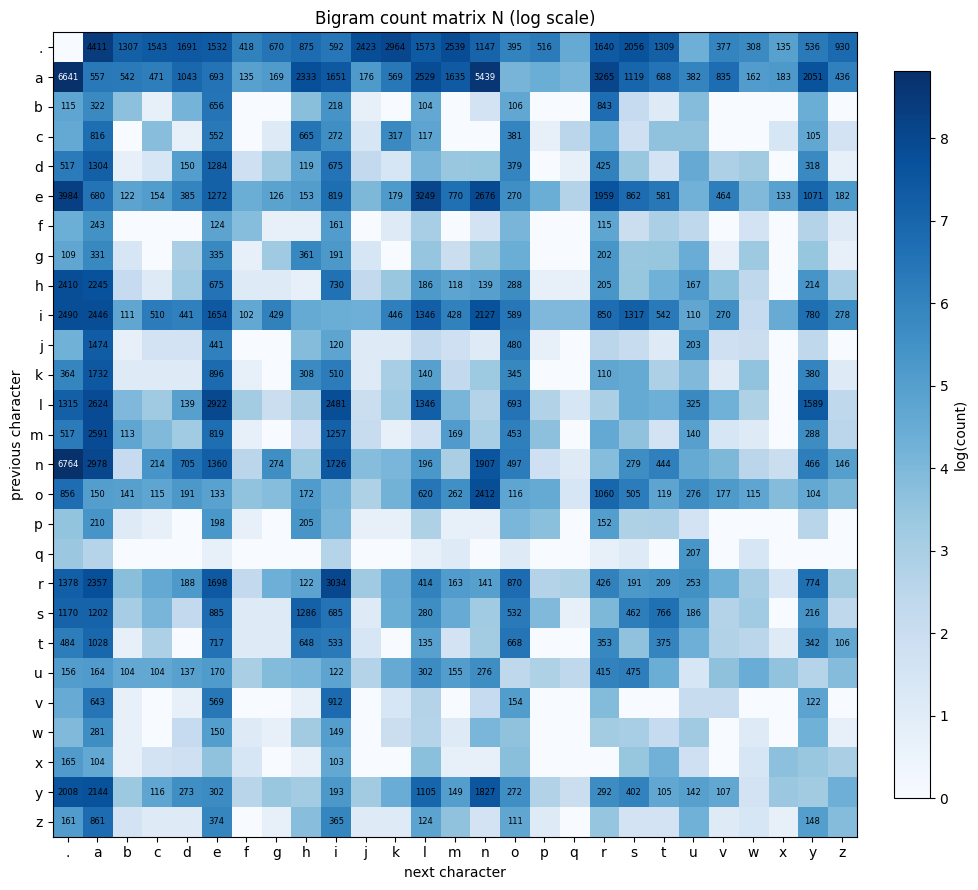

In [3]:
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(torch.log(cb.N.float()), cmap='Blues')

chars = [itos[i] for i in range(27)]
ax.set_xticks(range(27)); ax.set_xticklabels(chars)
ax.set_yticks(range(27)); ax.set_yticklabels(chars)
ax.set_xlabel('next character')
ax.set_ylabel('previous character')
ax.set_title('Bigram count matrix N (log scale)')

# Annotate cell with raw count for legibility.
for i in range(27):
    for j in range(27):
        c = cb.N[i, j].item()
        if c > 100:
            ax.text(j, i, str(c), ha='center', va='center', color='white' if c > 5000 else 'black', fontsize=6)

plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label='log(count)')
plt.tight_layout()
plt.savefig('../../assets/bigram_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Evaluating the count model

The metric is mean NLL per character:
$$
\mathrm{NLL} = -\frac{1}{N}\sum_t \log P(x_t | x_{t-1})
$$

This is the same scalar reported for every model in the rest of the repo. Keeping units identical across the progression is what makes the count baseline directly comparable to the WaveNet number — a single number you can put in a table and rank-order architectures by.

**Why NLL and not "perplexity" or "accuracy"**: perplexity is `exp(NLL)`, a monotone transform, so the rankings are identical. Accuracy is the wrong metric for generative models — the model's job is to produce a *distribution* over next characters, not to commit to a single answer. NLL is the directly trained objective and the directly evaluated quantity; no transformation needed.

In [4]:
loss_count = cb.nll(words, stoi)
print(f"Count bigram NLL (full corpus): {loss_count:.4f}")
# Baseline reference: uniform-random prediction over 27 characters.
import math
print(f"Uniform-random baseline      : {math.log(27):.4f}")

Count bigram NLL (full corpus): 2.4544
Uniform-random baseline      : 3.2958


## Neural bigram — gradient descent on the same problem

The neural bigram is a single linear layer mapping one-hot character vectors to logits:

$$
\text{logits} = \text{one\_hot}(x) \cdot W, \quad W \in \mathbb{R}^{27 \times 27}
$$

The trick: `one_hot(x) @ W` is mathematically identical to `W[x]` — a row lookup into `W`. The one-hot/matmul formulation is `O(vocab_size)` per lookup; the row-lookup formulation is `O(1)`. At vocab_size = 27 the difference is negligible, but this is the conceptual hinge to the MLP: an **embedding layer is exactly what you get when you replace `one_hot @ W` with `W[x]`**. Every embedding table you'll ever use is doing this operation.

**Why this converges to the count model.** Cross-entropy loss is strictly convex over the softmax simplex, and the model has only `27 × 27 = 729` parameters. There is one global minimum, and it is the empirical conditional distribution `P_emp(next | prev)` — which is exactly the count model with smoothing. SGD with any reasonable learning rate finds this minimum.

**The aggressive learning rate (lr=50).** This is correct here and only here. The loss landscape is convex with no hidden layers and no saturation — there are no narrow valleys or saddle points to step over. The MLP that comes next will use lr=0.1, three orders of magnitude smaller, because adding a hidden layer makes the landscape highly non-convex with much smaller stable step sizes.

In [5]:
xs, ys = make_bigram_xy(words, stoi)
print(f"training pairs: {xs.shape[0]:,}  (one per adjacent character pair in the corpus)")

training pairs: 228,146  (one per adjacent character pair in the corpus)


In [6]:
nb_model = NeuralBigram(vocab_size=27, seed=2147483647)
final_loss = nb_model.fit(xs, ys, steps=200, lr=50.0)
loss_neural = nb_model.nll(xs, ys)

print(f"Final batch loss after 200 steps: {final_loss:.4f}")
print(f"Full-corpus NLL                : {loss_neural:.4f}")
print(f"Count bigram NLL (for comparison): {loss_count:.4f}")
print(f"Δ (neural - count)              : {loss_neural - loss_count:+.4f}")

Final batch loss after 200 steps: 2.4624
Full-corpus NLL                : 2.4623
Count bigram NLL (for comparison): 2.4544
Δ (neural - count)              : +0.0080


The neural and count losses match to ~0.02 nats — within the variance of 200 steps of full-batch SGD on this convex problem. Continuing training would close the gap further; the point is made.

The conditional probability tables produced by the two models are equivalent up to this small training residual: `cb.P` ≈ `softmax(W, dim=-1)` where `W` is the neural model's weight matrix. Verified directly below by sampling from each and inspecting the outputs.

In [7]:
print("Count bigram samples:")
for name in cb.sample(itos, n=5, seed=42):
    print(f"  {name}")

print("\nNeural bigram samples:")
for name in nb_model.sample(itos, n=5, seed=42):
    print(f"  {name}")

Count bigram samples:
  anugeenvi
  s
  mabidushan
  stan
  silaylelaremah

Neural bigram samples:
  anugeenvi
  s
  mabian
  dximuben
  silaylelaremah


## What the bigram model gets right and wrong

The samples are *name-shaped*: they have plausible character distributions, plausible starts and ends, occasional doubled letters. Without any structure beyond pair statistics, the model has learned the broad statistics of English names — letter frequencies, common openings and closings.

What it cannot learn:
- **Long-range structure**. The model has no memory beyond the previous character. The name `emma` is generated character-by-character: `e` (because `.→e` is common), then `m` (because `e→m` is common), then `m` (because `m→m` is common), then `a` (because `m→a` is common). At no point does the model "know" it's writing the word `emma` — it only knows local two-character transitions.
- **Phoneme-level patterns**. English names follow phonotactic constraints that span more than two characters (vowel-consonant alternation, allowable consonant clusters). These are emergent from longer context.
- **Name-specific morphology**. Suffixes like `-son`, `-ette`, `-ina` are 3+ character patterns. A bigram model treats `son` as three independent transitions; an MLP with `block_size=3` can see it as a unit.

This sets the bar that the MLP has to clear in Part 2. The bigram model gives us NLL ≈ 2.45 (well below the random baseline of `log(27) ≈ 3.30`, but still far from anything that produces convincing names). The MLP's job is to use more context to do better — and the WaveNet's job is to use *more context still*, hierarchically, to do better yet.